# 02 — Mixed Layer Depth (MLD)

The **mixed layer** is the uppermost layer of the ocean that is well-mixed by wind and
surface cooling.  It is characterised by nearly uniform temperature and density.
Below it, temperature (and density) change rapidly — this transition zone is called the
**thermocline**.

The **Mixed Layer Depth (MLD)** is the depth at which the water column becomes stratified.
It is important for:
- Air–sea heat and gas exchange
- Biological productivity (phytoplankton need light AND nutrients)
- Ocean–atmosphere coupling

### How we calculate MLD

In this notebook, we will use the **temperature threshold method**:

> MLD = the depth at which temperature is **0.2 °C cooler** than the temperature at 10 dbar.

This is simple and robust, later you will have to calculate the MLD using density gradients.

In this notebook you will:
1. Download float profiles
2. Write a function to compute MLD for each profile
3. Plot MLD over time
4. Overlay MLD on the temperature contour plot

In [1]:
# --- Imports ---
from argopy import DataFetcher as ArgoDataFetcher

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 1 — Download and clean float data

In [2]:
# ---------------------------------------------------------------
# Change this WMO number to use a different float
# ---------------------------------------------------------------
WMO = 6903547

print(f'Downloading data for float {WMO} ...')
ds = ArgoDataFetcher(src='erddap').float(WMO).to_xarray()
df = ds.to_dataframe().reset_index()

# Clean: remove NaNs and out-of-range values
df = df.dropna(subset=['TEMP', 'PSAL', 'PRES'])
df = df[df['PRES'] <= 2000]
df = df[(df['TEMP'] > -5) & (df['TEMP'] < 45)]

# Attach a representative date to each cycle (median time of all measurements)
cycle_dates = (
    df.groupby('CYCLE_NUMBER')['TIME']
    .median()
    .reset_index()
    .rename(columns={'TIME': 'DATE'})
)
df = df.merge(cycle_dates, on='CYCLE_NUMBER')

print(f'Done!  {df["CYCLE_NUMBER"].nunique()} cycles loaded.')

Done!  77 cycles loaded.


## 2 — Define the MLD function

We write a reusable function that takes one profile (a subset of the DataFrame for a
single cycle) and returns the MLD in dbar.

This function takes a profile, and returns an array (a list of numbers) of the pressure in dbar of the mixed layer depth.

Use the function `calculated_mld_from_temp` in the future as a template to play with defining a mixed layer depth, so try and understand the code!

In [3]:

def calculate_mld_from_temp(profile, threshold=0.2, ref_depth=10):
    """
    Calculate the Mixed Layer Depth (MLD) using the temperature threshold method.

    Parameters
    ----------
    profile    : pandas DataFrame
                 One profile's data, must contain 'PRES' and 'TEMP' columns.
    threshold  : float
                 Temperature drop (°C) that defines the base of the mixed layer.
                 Default is 0.2 °C (de Boyer Montégut et al. 2004).
    ref_depth  : float
                 Reference pressure (dbar) for the surface temperature.
                 Default is 10 dbar (avoids the very surface skin layer).

    Returns
    -------
    mld : float
          Mixed layer depth in dbar, or NaN if it cannot be determined.
    """

    # Step 1: sort measurements from shallow to deep, makes our life easier
    profile = profile.sort_values('PRES').reset_index(drop=True)

    # Step 2: create a new data frame with measruments which are only +/- 5 dbar around the reference depth for this profile

    near_surface = profile[
        (profile['PRES'] >= ref_depth - 5) &
        (profile['PRES'] <= ref_depth + 5)
    ]

    # Step 3: (Optional, but a good backup) If there is no data around the reference depth, just take the shallowest data points
    if near_surface.empty:
        # Fall back to the shallowest available measurement
        near_surface = profile.iloc[[0]]

    # Step 4: Find the mean temperature around the reference depth of the profile
    T_ref = near_surface['TEMP'].mean()

    # Step 5: (Optional, but good to have) if the mean temperature is empty, return nan (nothing)
    if np.isnan(T_ref):
        return np.nan

    # Step 6: Creat a new data frame with only the measurements above the threshold temperature for this profile
    mixed_layer = profile[profile['TEMP'] >= T_ref - threshold]

    # Step 7: (Optional, but good to have) if there is no data above the threshold temperature, return nan (nothing)
    if mixed_layer.empty:
        return np.nan

    # Step 8: Return the deepest point in the mixed layer, i.e where the temperature fufills the criteria
    return mixed_layer['PRES'].max()


print('MLD function defined.')
print(f'Threshold used: 0.2 °C below the temperature at 10 dbar')

MLD function defined.
Threshold used: 0.2 °C below the temperature at 10 dbar


## 3 — Calculate MLD for every cycle

In [4]:
# Loop over every cycle and compute MLD
results = []

for cycle, group in df.groupby('CYCLE_NUMBER'):
    mld  = calculate_mld_from_temp(group)
    date = group['DATE'].iloc[0]
    results.append({'CYCLE_NUMBER': cycle, 'DATE': date, 'MLD': mld})

mld_df = pd.DataFrame(results)

# Remove cycles where MLD could not be computed
mld_df = mld_df.dropna(subset=['MLD'])

print(f'MLD computed for {len(mld_df)} cycles.')
print(f'MLD range: {mld_df["MLD"].min():.0f} – {mld_df["MLD"].max():.0f} dbar')
mld_df.head()

MLD computed for 77 cycles.
MLD range: 10 – 424 dbar


,CYCLE_NUMBER,DATE,MLD
0,1,2018-06-02 20:17:00,53.700001
1,2,2018-06-12 20:14:00,19.700001
2,3,2018-06-22 20:17:00,31.900000
3,4,2018-07-02 20:17:00,16.700001
4,5,2018-07-12 20:16:00,45.200001


## 4 — Plot MLD over time

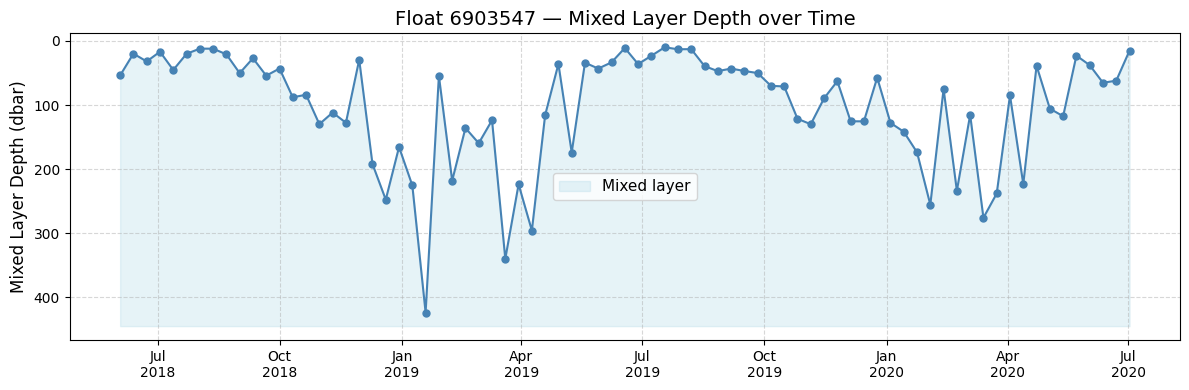

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(mld_df['DATE'], mld_df['MLD'],
        color='steelblue', linewidth=1.5, zorder=2)

ax.scatter(mld_df['DATE'], mld_df['MLD'],
           color='steelblue', s=25, zorder=3)

# Shade the area below the MLD line to make it visually clear
ax.fill_between(mld_df['DATE'], mld_df['MLD'], mld_df['MLD'].max() * 1.05,
                color='lightblue', alpha=0.3, label='Mixed layer')

ax.invert_yaxis()   # Surface at top
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax.set_ylabel('Mixed Layer Depth (dbar)', fontsize=12)
ax.set_title(f'Float {WMO} — Mixed Layer Depth over Time', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5 — Overlay MLD on the temperature contour plot

Seeing MLD on top of the temperature field is one of the most informative ocean plots
you can make: it shows how deep the surface warming or cooling penetrates.

In [6]:
# --- Build the temperature contour grid (same approach as notebook 01) ---

PRES_MIN  =   0
PRES_MAX  = 500
PRES_STEP =   5
pres_grid = np.arange(PRES_MIN, PRES_MAX + PRES_STEP, PRES_STEP)

cycles = sorted(df['CYCLE_NUMBER'].unique())
dates  = []
temp_grid = np.full((len(pres_grid), len(cycles)), np.nan)

for col_idx, cycle in enumerate(cycles):
    profile = (
        df[df['CYCLE_NUMBER'] == cycle]
        .dropna(subset=['TEMP', 'PRES'])
        .sort_values('PRES')
    )
    if len(profile) < 3:
        continue
    temp_grid[:, col_idx] = np.interp(
        pres_grid,
        profile['PRES'].values,
        profile['TEMP'].values,
        left=np.nan, right=np.nan
    )
    dates.append(profile['DATE'].iloc[0])

dates = np.array(dates)

print(f'Contour grid shape: {temp_grid.shape}')

Contour grid shape: (101, 77)


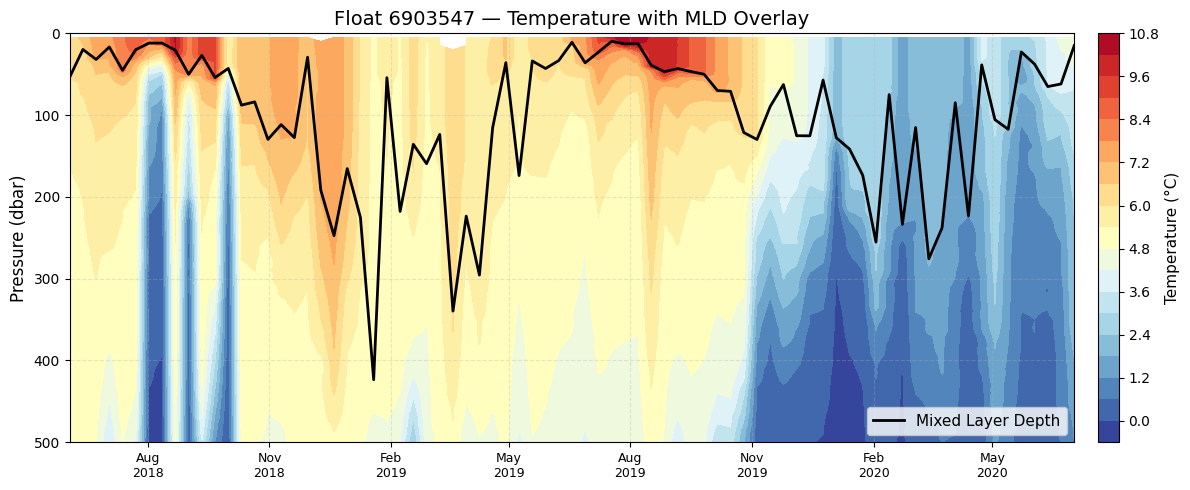

Figure saved to mld_overlay.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

# --- Filled temperature contour ---
cf = ax.contourf(dates, pres_grid, temp_grid, levels=20, cmap='RdYlBu_r')
cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('Temperature (°C)', fontsize=11)

# --- MLD overlay ---
# Align MLD dates with the contour dates (use only cycles that appear in both)
ax.plot(
    mld_df['DATE'], mld_df['MLD'],
    color='black', linewidth=2, label='Mixed Layer Depth',
    zorder=5
)

ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), fontsize=9)

ax.set_ylabel('Pressure (dbar)', fontsize=12)
ax.set_title(f'Float {WMO} — Temperature with MLD Overlay', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('mld_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to mld_overlay.png')

---

## Exercises

1. **Change the threshold** — Try `threshold=0.5` or `threshold=0.1`. How sensitive is the MLD to this choice?

**Next notebook:** `03_regional_floats.ipynb`